# Analisis Dataset Kematian Akibat Senjata Api di AS (2012-2014)



> Abdulhadi Muntashir
> 3337230041



In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

dataset_path = "Dataset UTS.csv"

# Function to load the dataset
def load_dataset():
    try:
        # Read the CSV file
        df = pd.read_csv(dataset_path)
        return df
    except FileNotFoundError:
        print(f"Error: The file '{dataset_path}' was not found.")
        return None
    except Exception as e:
        print(f"An error occurred while reading the dataset: {e}")
        return None

# Load the dataset
df = load_dataset()

# 1. Analisis jumlah baris dan kolom, periksa nilai yang hilang

In [38]:
print("\n--- Pertanyaan 1: Dataset Analysis ---")
rows, columns = df.shape
print(f"Dataset dimensions: {rows} rows and {columns} columns")

# Check for missing values
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

if total_missing > 0:
    print("\nMissing values by column:")
    for column, count in missing_values.items():
        if count > 0:
            print(f"- {column}: {count} missing values")
    print(f"\nTotal missing values: {total_missing}")
else:
    print("No missing values found in the dataset.")


--- Pertanyaan 1: Dataset Analysis ---
Dataset dimensions: 100798 rows and 11 columns

Missing values by column:
- intent: 1 missing values
- age: 18 missing values
- place: 1384 missing values
- education: 1422 missing values

Total missing values: 2825


# 2. Menangani nilai yang hilang menggunakan mode (nilai yang paling sering muncul)

In [39]:
print("\n--- PERTANYAAN 2: Menangani Nilai yang Hilang ---")
columns_with_missing = [column for column in df.columns if df[column].isnull().sum() > 0]

if columns_with_missing:
    df_cleaned = df.copy()
    for column in columns_with_missing:
        mode_value = df[column].mode()[0]
        df_cleaned[column] = df_cleaned[column].fillna(mode_value)
        print(f"Filled missing values in '{column}' with the mode value: {mode_value}")

    # Verify missing values are fixed
    remaining_missing = df_cleaned.isnull().sum().sum()
    print(f"\nRemaining missing values after handling: {remaining_missing}")

    # Use the cleaned dataframe for further analysis
    df = df_cleaned
else:
    print("No missing values to handle.")


--- PERTANYAAN 2: Menangani Nilai yang Hilang ---
Filled missing values in 'intent' with the mode value: Suicide
Filled missing values in 'age' with the mode value: 22.0
Filled missing values in 'place' with the mode value: Home
Filled missing values in 'education' with the mode value: HS/GED

Remaining missing values after handling: 0


# 3. Hitung rata-rata kematian akibat senjata api berdasarkan penyebabnya dari tahun 2012 hingga 2014


--- PERTANYAAN 3: Rata-rata Kematian Akibat Senjata Api Berdasarkan Penyebabnya (2012-2014) ---
Rata-rata kematian tahunan akibat senjata api berdasarkan penyebabnya (2012-2014):
- Suicide: 21058.67
- Homicide: 11725.33
- Accidental: 546.33
- Undetermined: 269.00


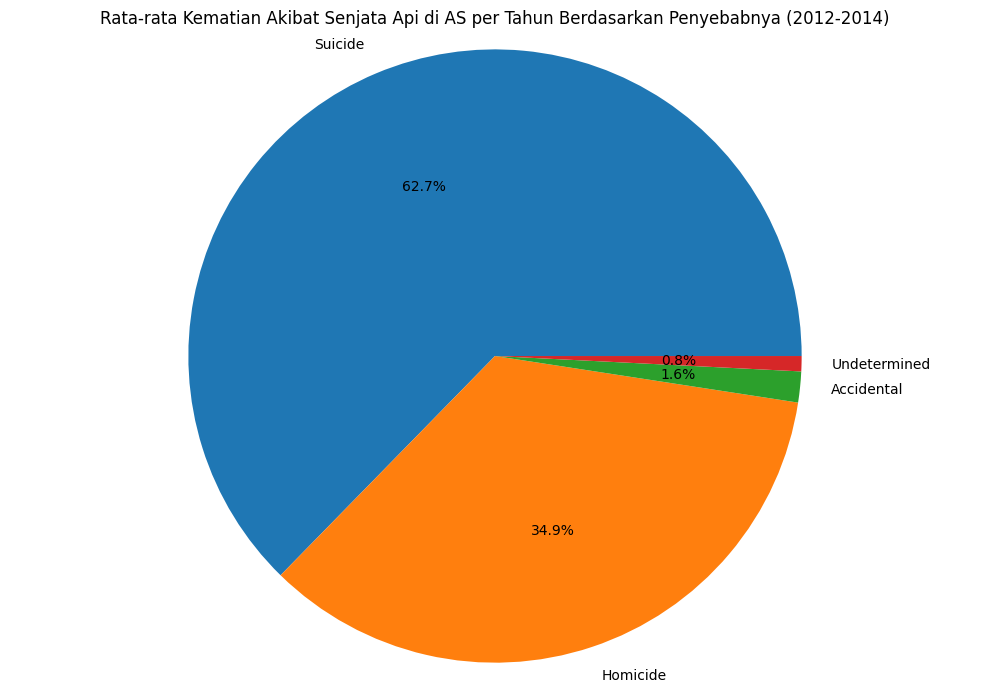

In [40]:
print("\n--- PERTANYAAN 3: Rata-rata Kematian Akibat Senjata Api Berdasarkan Penyebabnya (2012-2014) ---")

# Filter data for years 2012-2014
df_2012_2014 = df[(df['year'] >= 2012) & (df['year'] <= 2014)]

# Group by intent and count occurrences
deaths_by_intent = df_2012_2014['intent'].value_counts().reset_index()
deaths_by_intent.columns = ['intent', 'count']

# Calculate the average deaths per year
deaths_by_intent['average_per_year'] = deaths_by_intent['count'] / 3  # 3 years (2012-2014)

print("Rata-rata kematian tahunan akibat senjata api berdasarkan penyebabnya (2012-2014):")
for index, row in deaths_by_intent.iterrows():
    print(f"- {row['intent']}: {row['average_per_year']:.2f}")

# Create pie chart visualization
plt.figure(figsize=(10, 7))
plt.pie(deaths_by_intent['average_per_year'], labels=deaths_by_intent['intent'], autopct='%1.1f%%')
plt.title('Rata-rata Kematian Akibat Senjata Api di AS per Tahun Berdasarkan Penyebabnya (2012-2014)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.tight_layout()  # This will be the last line and won't return a visible value

Visualisasi grafik pie memberikan beberapa wawasan yang penting tentang kematian akibat senjata api di AS rata-rata per tahun dari 2012 hingga 2014 berdasarkan penyebabnya. Berikut adalah wawasan yang saya dapat:

1. **Suicide (Bunuh Diri)**: Segmen terbesar dari grafik ini, mencakup 62.7% dari semua kematian akibat senjata api, menunjukkan bahwa bunuh diri adalah penyebab utama kematian akibat senjata api di AS selama periode waktu ini. Ini menekankan pentingnya strategi pencegahan bunuh diri dan akses ke sumber daya kesehatan mental.

2. **Homicide (Pembunuhan)**: Segmen kedua terbesar, 34.9%, menunjukkan bahwa pembunuhan juga merupakan penyebab signifikan dari kematian akibat senjata api. Ini menyoroti kebutuhan akan upaya pencegahan kekerasan dan kebijakan pengendalian senjata.

3. **Kecelakaan dan Tak Ditentukan**: Segmen yang lebih kecil, 1.6% untuk kecelakaan dan 0.8% untuk penyebab yang tidak ditentukan, menunjukkan bahwa meskipun tidak sebesar bunuh diri dan pembunuhan, kecelakaan dan kasus tak ditentukan juga berkontribusi pada kematian akibat senjata api. Ini menunjukkan pentingnya kesadaran keselamatan senjata api dan investigasi yang tepat pada kasus kematian.

4. **Distribusi Prosentase**: Grafik pie memberikan gambaran yang jelas tentang distribusi proporsional dari penyebab kematian akibat senjata api. Dengan sebagian besar kematian disebabkan oleh bunuh diri dan pembunuhan, ini menunjukkan bahwa upaya pencegahan harus difokuskan pada faktor-faktor tersebut.

5. **Warna yang Digunakan**: Penggunaan warna yang berbeda untuk setiap segmen (biru untuk bunuh diri, orange untuk pembunuhan, hijau untuk kecelakaan, dan merah untuk tak ditentukan) membantu dalam memvisualisasikan dan membedakan dengan mudah setiap kategori.

6. **Implikasi Kebijakan**: Data ini dapat digunakan oleh pembuat kebijakan, organisasi kesehatan masyarakat, dan kelompok advokasi untuk memprioritaskan sumber daya dan strategi pencegahan. Misalnya, data ini mungkin mendukung kebutuhan akan lebih banyak layanan kesehatan mental atau program pencegahan kekerasan.

7. **Pemahaman Umum Publik**: Visualisasi ini membantu publik memahami skala relatif dari setiap penyebab kematian akibat senjata api, yang dapat memengaruhi opini publik dan diskusi tentang kebijakan senjata api.

Dalam kesimpulan, grafik pie memberikan gambaran yang jelas tentang penyebab kematian akibat senjata api di AS dan menunjukkan bahwa bunuh diri dan pembunuhan adalah penyebab utama yang memerlukan perhatian khusus dalam upaya pencegahan dan pengendalian.

# 4. Hitung persentase kematian akibat senjata bunuh diri berdasarkan tahun (2012-2014)


--- PERTANYAAN 4: Jumlah Kematian Akibat Bunuh Diri Akibat Senjata Api Berdasarkan Tahun (2012-2014) ---
Persentase kematian akibat senjata api akibat bunuh diri menurut tahun:
- 2012: 61.57%
- 2013: 62.96%
- 2014: 63.50%


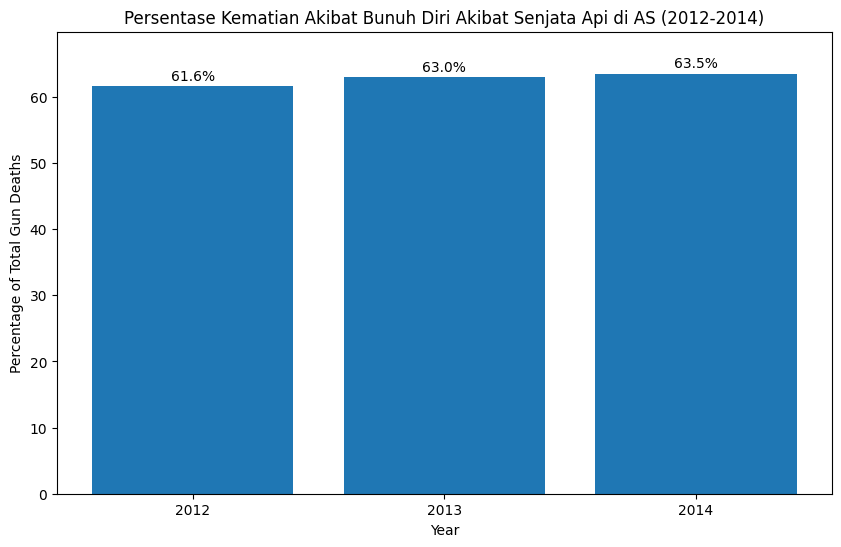

In [41]:
print("\n--- PERTANYAAN 4: Jumlah Kematian Akibat Bunuh Diri Akibat Senjata Api Berdasarkan Tahun (2012-2014) ---")

# Filter for suicides
suicide_data = df[(df['year'] >= 2012) & (df['year'] <= 2014) & (df['intent'] == 'Suicide')]

# Group by year
suicide_by_year = suicide_data.groupby('year').size().reset_index(name='suicide_count')

# Get total deaths by year
total_by_year = df[(df['year'] >= 2012) & (df['year'] <= 2014)].groupby('year').size().reset_index(name='total_count')

# Merge and calculate percentages
suicide_percentage = pd.merge(suicide_by_year, total_by_year, on='year')
suicide_percentage['percentage'] = (suicide_percentage['suicide_count'] / suicide_percentage['total_count'] * 100)

print("Persentase kematian akibat senjata api akibat bunuh diri menurut tahun:")
for index, row in suicide_percentage.iterrows():
    print(f"- {int(row['year'])}: {row['percentage']:.2f}%")

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(suicide_percentage['year'].astype(str), suicide_percentage['percentage'])

# Add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

plt.title('Persentase Kematian Akibat Bunuh Diri Akibat Senjata Api di AS (2012-2014)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Gun Deaths')
plt.ylim(0, max(suicide_percentage['percentage']) * 1.1);  # Add some space above the highest bar

Visualisasi grafik batang ini memberikan beberapa wawasan penting tentang persentase kematian akibat senjata api yang disebabkan oleh bunuh diri di AS dari tahun 2012 hingga 2014. Berikut adalah wawasan yang dapat diambil:

### 1. **Tren Kenaikan Bunuh Diri**
   - Grafik menunjukkan bahwa persentase kematian akibat senjata api yang disebabkan oleh bunuh diri mengalami kenaikan dari tahun ke tahun:
     - **2012**: 61,6%
     - **2013**: 63,0%
     - **2014**: 63,5%
   - Meskipun kenaikan tersebut relatif kecil (kurang dari 2% dalam dua tahun), tren ini menunjukkan bahwa bunuh diri menggunakan senjata api menjadi semakin dominan sebagai penyebab kematian akibat senjata api selama periode ini.

### 2. **Dominasi Bunuh Diri sebagai Penyebab Kematian**
   - Bunuh diri secara konsisten menjadi penyebab utama kematian akibat senjata api di AS selama tiga tahun yang ditampilkan. Ini menekankan bahwa senjata api adalah metode yang sering digunakan dalam kasus bunuh diri.
   - Hal ini juga mengindikasikan bahwa upaya pencegahan bunuh diri harus menjadi prioritas dalam strategi pengendalian senjata api.

### 3. **implikasi Kebijakan dan Kesehatan Masyarakat**
   - Data ini mendukung kebutuhan akan kebijakan yang lebih ketat mengenai akses senjata api, terutama bagi mereka yang berisiko tinggi melakukan bunuh diri.
   - Pentingnya intervensi kesehatan mental yang lebih baik dan pendidikan tentang keselamatan senjata api di rumah tangga.

### 4. **Perbandingan Tahunan**
   - Grafik memudahkan perbandingan tahunan melalui batang dengan warna yang sama dan skala yang konsisten. Kenaikan dari 61,6% ke 63,5% terlihat jelas meskipun nilai-nilai tersebut relatif dekat.
   - Tidak ada penurunan yang signifikan selama periode ini, yang menunjukkan bahwa masalah bunuh diri menggunakan senjata api belum terselesaikan dengan baik.

### 5. **Visualisasi Efektif**
   - Penggunaan grafik batang dengan warna biru yang konsisten membuat data mudah dibaca dan memungkinkan perbandingan cepat antara tahun.
   - Label persentase di atas setiap batang memudahkan pembaca untuk langsung melihat nilai spesifik tanpa perlu mengacu pada sumbu Y.

### 6. **Konteks Lebih Luas**
   - Data ini dapat digunakan untuk mendukung diskusi tentang hubungan antara akses senjata api dan tingkat bunuh diri. Studi telah menunjukkan bahwa kehadiran senjata api di rumah dapat meningkatkan risiko bunuh diri, terutama karena senjata api memiliki tingkat fatalitas yang tinggi.

### 7. **Kesadaran Publik**
   - Visualisasi ini dapat membantu meningkatkan kesadaran publik tentang sejauh mana senjata api berkontribusi pada kasus bunuh diri, yang mungkin kurang disadari dibandingkan dengan pembunuhan atau kekerasan lainnya.

### **Kesimpulan**
Grafik batang ini secara jelas menunjukkan bahwa bunuh diri adalah penyebab utama kematian akibat senjata api di AS selama periode 2012-2014, dengan tren kenaikan yang konsisten. Informasi ini sangat penting untuk pembuat kebijakan, praktisi kesehatan masyarakat, dan organisasi pencegahan bunuh diri untuk merumuskan strategi yang lebih efektif dalam mengurangi kematian akibat senjata api, terutama yang terkait dengan bunuh diri.

# Tindakan yang direkomendasikan untuk pemerintah AS:
1. Memperkuat layanan kesehatan mental dan membuatnya lebih mudah diakses
2. Menerapkan pemeriksaan latar belakang yang lebih ketat untuk pembelian senjata api
3. Meningkatkan kesadaran tentang pencegahan bunuh diri
4. Mempertimbangkan masa tunggu untuk pembelian senjata api
5. Mendanai penelitian tentang kekerasan senjata api sebagai masalah kesehatan masyarakat
6. Mendukung program intervensi berbasis masyarakat